In [1]:
# ============================================================
#  Global Equity Portfolio Analysis
#  "The Magnificent 7 vs The World"
# ============================================================
#  Author    : Kesidis Angelos
#  Stocks    : AAPL, MSFT, GOOGL, AMZN, NVDA, META, TSLA
#  Benchmarks: S&P 500 (^GSPC), NASDAQ (^IXIC), DAX (^GDAXI)
#  Period    : 2018-01-01 to 2023-12-31
#  Purpose   : Returns analysis, portfolio construction,
#              and benchmark comparison
# ============================================================

In [14]:
# ── IMPORTS ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
 
%matplotlib inline

In [15]:
# ============================================================
# SECTION 1 — DATA COLLECTION & CLEANING
# ============================================================
 
stocks     = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA"]
benchmarks = ["^GSPC", "^IXIC", "^GDAXI"]
assets     = stocks + benchmarks
 
start = "2018-01-01"
end   = "2023-12-31"
 
data = yf.download(assets, start=start, end=end)["Close"]
 
print("Shape   :", data.shape)
print("Columns :", list(data.columns))
print("\n--- First 5 rows ---")
print(data.head())
print("\n--- Last 5 rows ---")
print(data.tail())
print("\n--- Missing values per column ---")
print(data.isnull().sum())

[*********************100%***********************]  10 of 10 completed

Shape   : (1549, 10)
Columns : ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', '^GDAXI', '^GSPC', '^IXIC']

--- First 5 rows ---
Ticker           AAPL       AMZN      GOOGL        META       MSFT      NVDA  \
Date                                                                           
2018-01-02  40.267071  59.450500  53.220634  180.007401  78.699905  4.928266   
2018-01-03  40.260067  60.209999  54.128632  183.232071  79.066162  5.252614   
2018-01-04  40.447067  60.479500  54.338886  182.894745  79.762077  5.280303   
2018-01-05  40.907566  61.457001  55.059433  185.395111  80.750961  5.325048   
2018-01-08  40.755634  62.343498  55.253830  186.813965  80.833366  5.488213   

Ticker           TSLA        ^GDAXI        ^GSPC        ^IXIC  
Date                                                           
2018-01-02  21.368668  12871.389648  2695.810059  7006.899902  
2018-01-03  21.150000  12978.209961  2713.060059  7065.529785  
2018-01-04  20.974667  13167.889648  2723.98

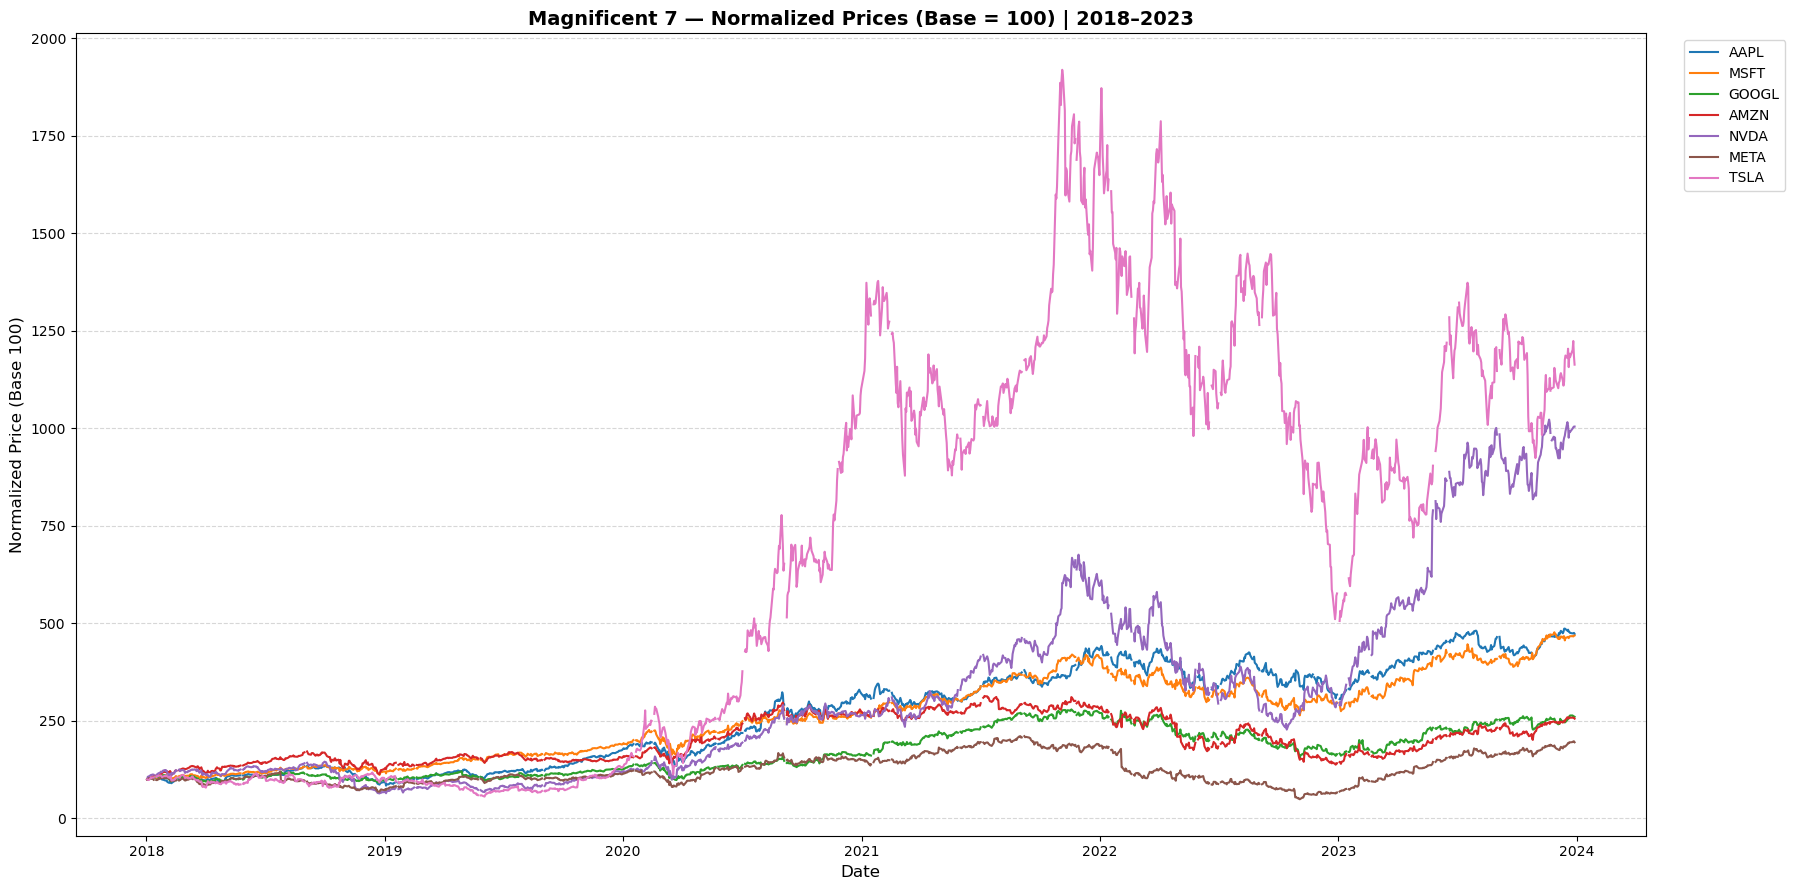

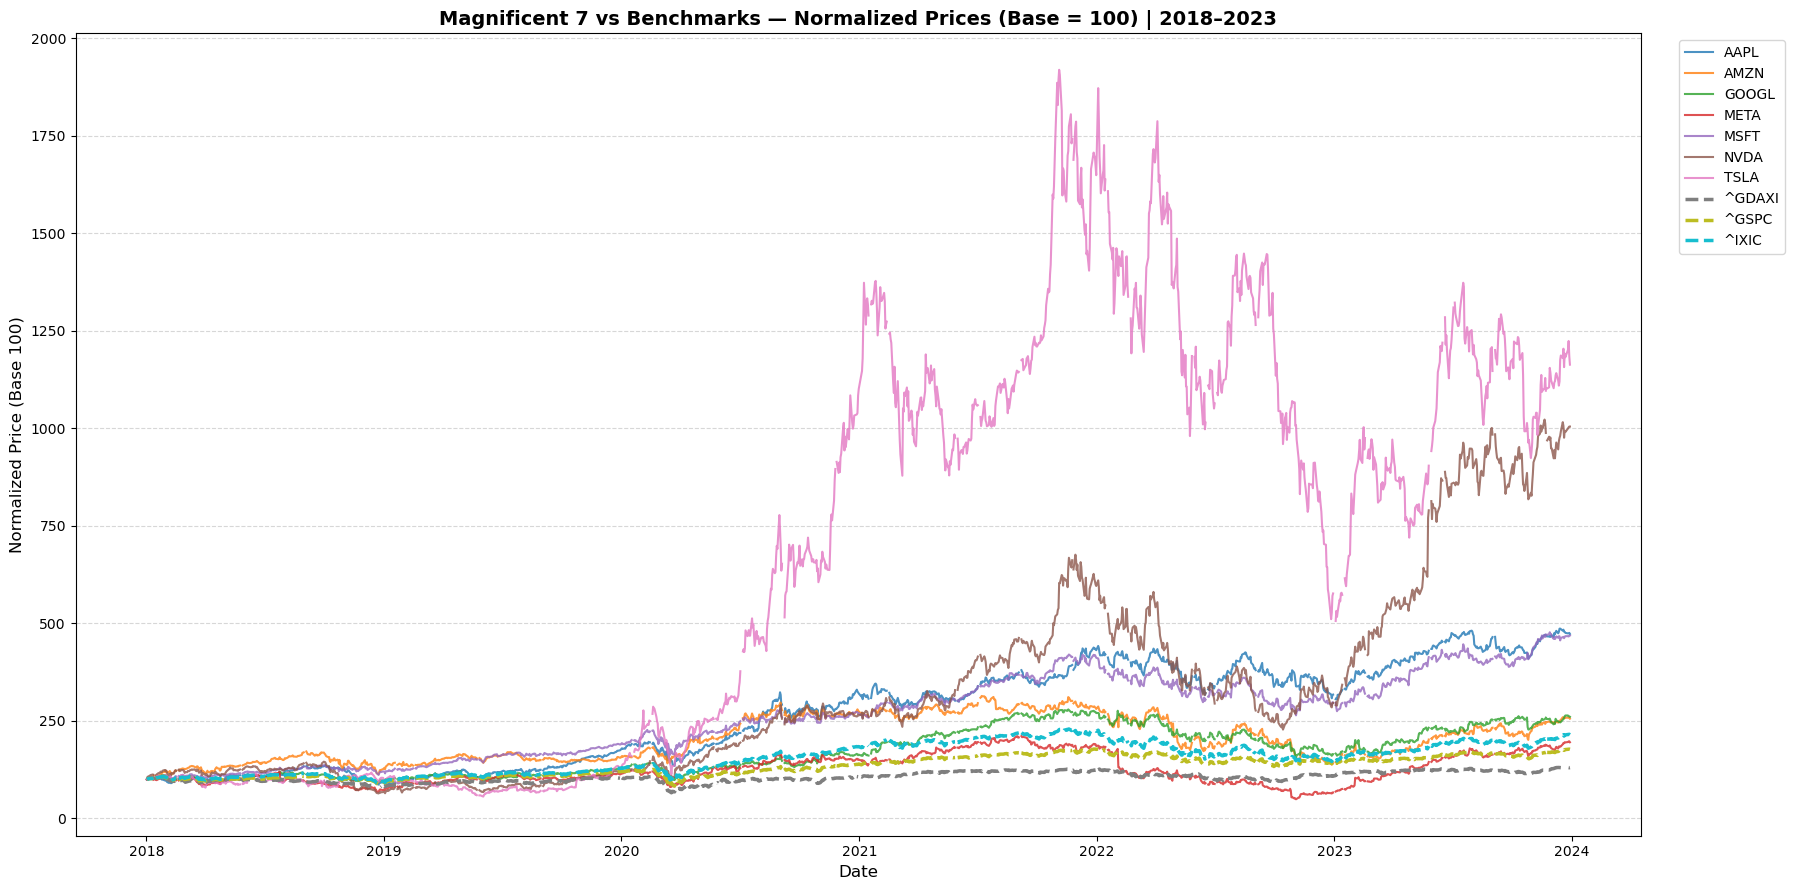

In [16]:
# ============================================================
# SECTION 2 — NORMALIZATION & VISUALIZATION
# ============================================================
 
# ── Plot 1: Magnificent 7 stocks only ───────────────────────
normalized_stocks = (data[stocks] / data[stocks].iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalized_stocks.columns:
    plt.plot(normalized_stocks[col], label=col)
 
plt.title("Magnificent 7 — Normalized Prices (Base = 100) | 2018–2023", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()
 
# ── Plot 2: All assets (stocks + benchmarks) ────────────────
normalized_all = (data / data.iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalized_all.columns:
    if col in benchmarks:
        plt.plot(normalized_all[col], label=col, linewidth=2.5, linestyle="--")
    else:
        plt.plot(normalized_all[col], label=col, alpha=0.8)
 
plt.title("Magnificent 7 vs Benchmarks — Normalized Prices (Base = 100) | 2018–2023",
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()

--- Daily Simple Returns (first 5 rows) ---
Ticker          AAPL      AMZN     GOOGL      META      MSFT      NVDA  \
Date                                                                     
2018-01-03 -0.000174  0.012775  0.017061  0.017914  0.004654  0.065814   
2018-01-04  0.004645  0.004476  0.003884 -0.001841  0.008802  0.005271   
2018-01-05  0.011385  0.016163  0.013260  0.013671  0.012398  0.008474   
2018-01-08 -0.003714  0.014425  0.003531  0.007653  0.001020  0.030641   
2018-01-09 -0.000115  0.004676 -0.001274 -0.002177 -0.000680 -0.000270   

Ticker          TSLA    ^GDAXI     ^GSPC     ^IXIC  
Date                                                
2018-01-03 -0.010233  0.008299  0.006399  0.008367  
2018-01-04 -0.008290  0.014615  0.004029  0.001752  
2018-01-05  0.006230  0.011524  0.007034  0.008286  
2018-01-08  0.062638  0.003614  0.001662  0.002919  
2018-01-09 -0.008085  0.001332  0.001303  0.000865  

--- Daily Log Returns (first 5 rows) ---
Ticker          AAPL    

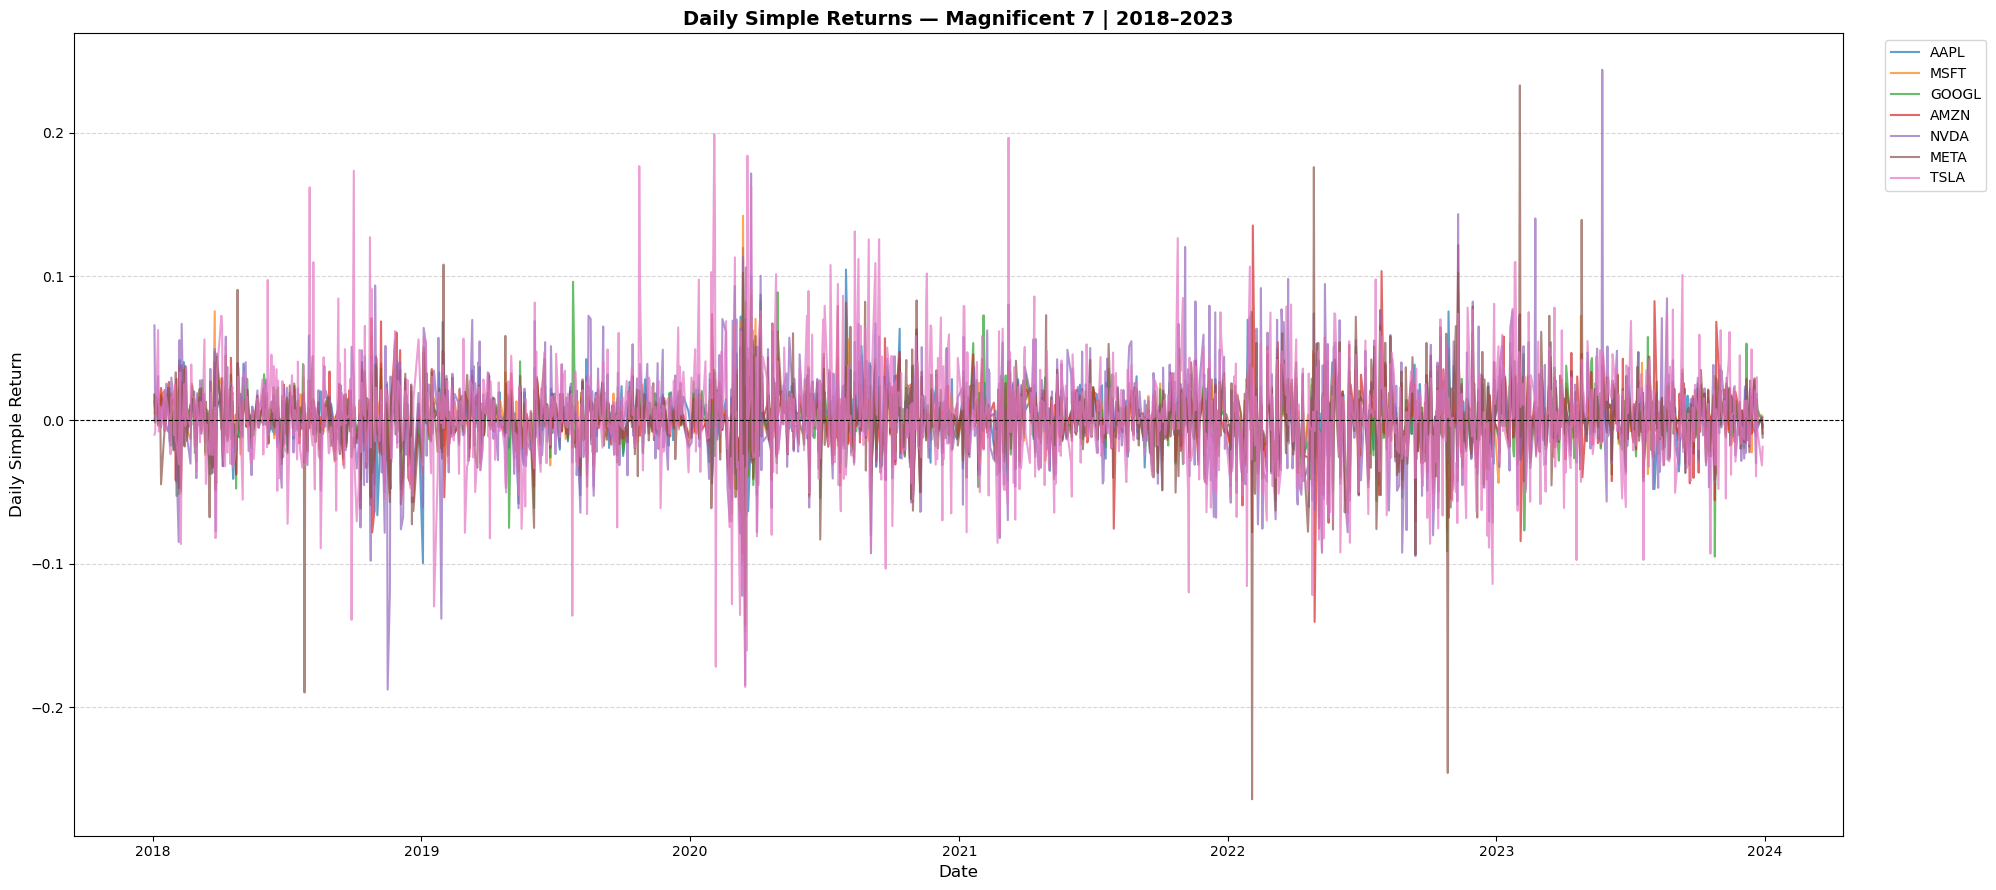

In [17]:
# ============================================================
# SECTION 3 — RETURNS ANALYSIS
# ============================================================
 
# ── Simple Returns ───────────────────────────────────────────
simple_returns = (data / data.shift(1) - 1).dropna()
 
print("--- Daily Simple Returns (first 5 rows) ---")
print(simple_returns.head())
 
# ── Log Returns ──────────────────────────────────────────────
log_returns = np.log(data / data.shift(1)).dropna()
 
print("\n--- Daily Log Returns (first 5 rows) ---")
print(log_returns.head())
 
# ── Plot: Daily Simple Returns ───────────────────────────────
plt.figure(figsize=(20, 9))
for col in stocks:                              
    plt.plot(simple_returns[col], label=col, alpha=0.7)
 
plt.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
plt.title("Daily Simple Returns — Magnificent 7 | 2018–2023", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Simple Return", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()

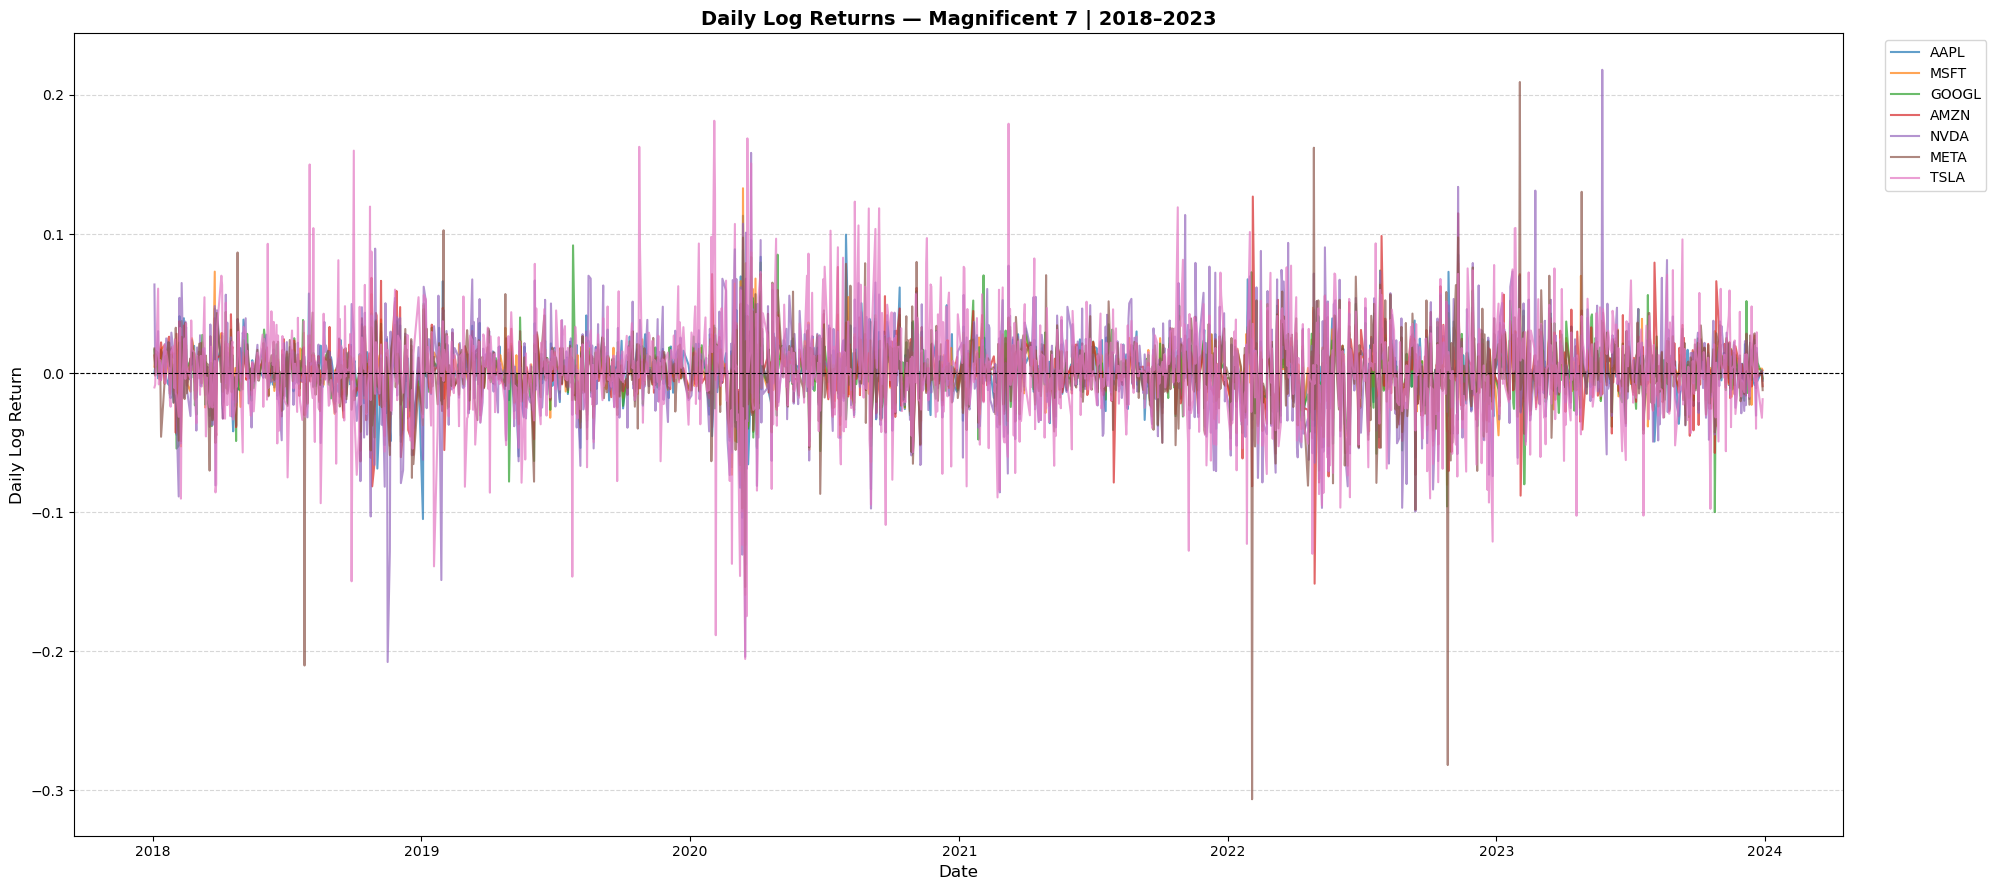


--- Individual Stock Annual Returns (Ranked) ---
       Annual Simple Return (%) Annual Log Return (%)
Ticker                                               
TSLA                     53.03%                33.76%
NVDA                     50.36%                36.84%
MSFT                     31.84%                27.26%
AAPL                     29.32%                24.32%
GOOGL                    18.38%                13.47%
AMZN                     15.67%                 9.55%
META                      15.2%                 5.69%


In [18]:
# ── Plot: Daily Log Returns ───────────────────────────────────
plt.figure(figsize=(20, 9))
for col in stocks:
    plt.plot(log_returns[col], label=col, alpha=0.7)
 
plt.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
plt.title("Daily Log Returns — Magnificent 7 | 2018–2023", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Log Return", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()
# ── Annualized Returns (× 250 trading days) ──────────────────
annual_simple = simple_returns[stocks].mean() * 250
annual_log    = log_returns[stocks].mean()    * 250
 
# Ranking table — stocks only
summary = pd.DataFrame({
    "Annual Simple Return (%)": (annual_simple * 100).round(2),
    "Annual Log Return (%)":    (annual_log    * 100).round(2),
}).sort_values(by="Annual Simple Return (%)", ascending=False)
 
# Format as strings for display
summary_display = summary.applymap(lambda x: f"{x}%")
 
print("\n--- Individual Stock Annual Returns (Ranked) ---")
print(summary_display.to_string())

In [19]:
# ============================================================
# SECTION 4 — PORTFOLIO CONSTRUCTION
# ============================================================
 
n = len(stocks)
weights = np.array([1 / n] * n)
 
print(f"\nNumber of stocks  : {n}")
print(f"Weight per stock  : {round(weights[0], 6)}")
print(f"Sum of weights    : {round(sum(weights), 10)}")   # must equal 1.0
 
portfolio_return = np.dot(annual_simple[stocks], weights)
 
print(f"\nPortfolio Annual Return (Equal-Weight): {round(portfolio_return * 100, 2)}%")


Number of stocks  : 7
Weight per stock  : 0.142857
Sum of weights    : 1.0

Portfolio Annual Return (Equal-Weight): 30.54%


--- Portfolio vs Benchmark Indices ---
              Asset  Annual Return (%)
My Portfolio (Mag7)              30.54
             NASDAQ              12.33
            S&P 500              10.42
                DAX               6.15


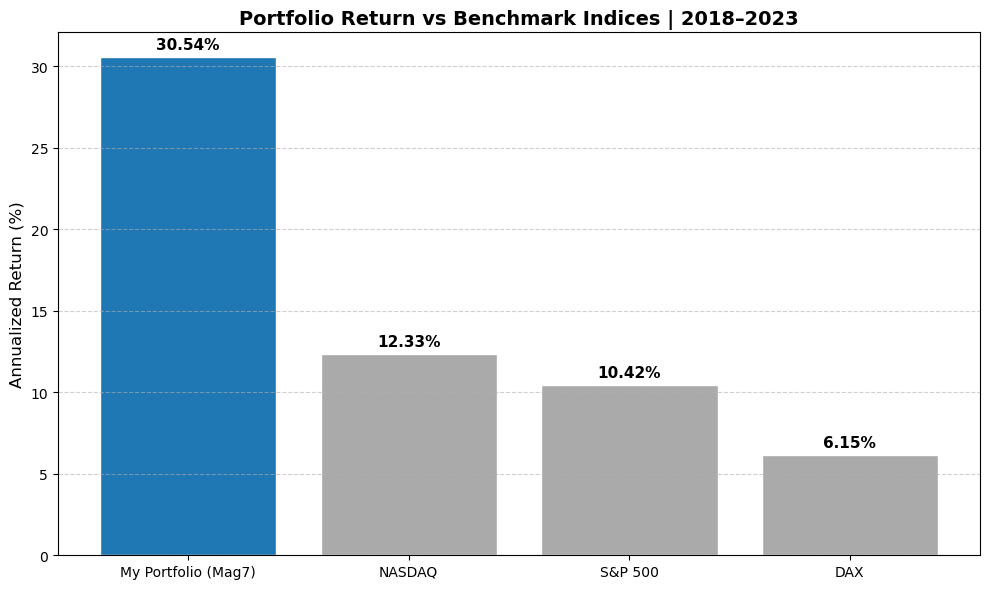

In [20]:
# ============================================================
# SECTION 5 — BENCHMARK COMPARISON
# ============================================================
 
annual_log_all   = log_returns.mean() * 250          
annual_log_bench = {
    "S&P 500": annual_log_all["^GSPC"],
    "NASDAQ":  annual_log_all["^IXIC"],
    "DAX":     annual_log_all["^GDAXI"],
}
 
comparison_data = {
    "My Portfolio (Mag7)": portfolio_return,
    **annual_log_bench
}
 
comparison_df = pd.DataFrame(
    list(comparison_data.items()),
    columns=["Asset", "Annual Return"]
)
comparison_df["Annual Return (%)"] = (comparison_df["Annual Return"] * 100).round(2)
comparison_df = comparison_df.sort_values(by="Annual Return (%)", ascending=False).reset_index(drop=True)
 
print("--- Portfolio vs Benchmark Indices ---")
print(comparison_df[["Asset", "Annual Return (%)"]].to_string(index=False))
 
# ── Bar Chart: Portfolio vs Benchmarks ───────────────────────
colors = ["#1f77b4" if asset == "My Portfolio (Mag7)" else "#AAAAAA"
          for asset in comparison_df["Asset"]]
 
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df["Asset"], comparison_df["Annual Return (%)"], color=colors, edgecolor="white")
 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             yval + 0.3,
             f"{round(yval, 2)}%",
             ha="center", va="bottom", fontweight="bold", fontsize=11)
 
plt.title("Portfolio Return vs Benchmark Indices | 2018–2023",
          fontsize=14, fontweight="bold")
plt.ylabel("Annualized Return (%)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

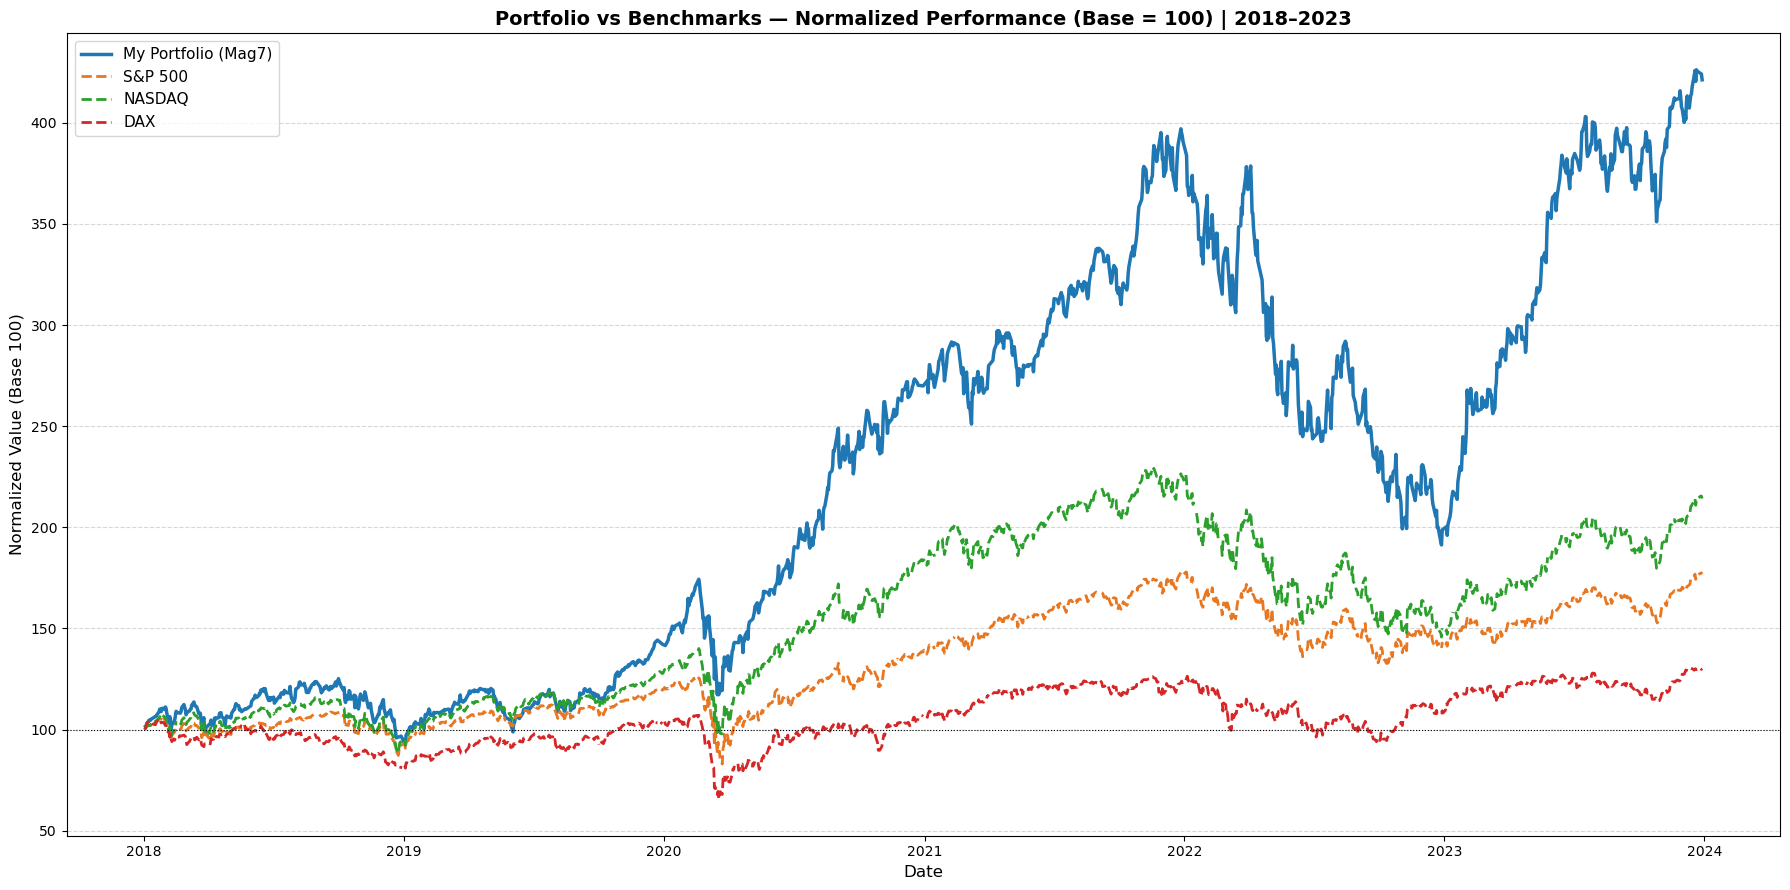

In [21]:
# ── Normalized Line Chart: Portfolio vs Benchmarks ───────────
portfolio_daily = (simple_returns[stocks] * weights).sum(axis=1)
portfolio_cumulative = (1 + portfolio_daily).cumprod() * 100   # base = 100
 
plt.figure(figsize=(18, 9))
plt.plot(portfolio_cumulative, label="My Portfolio (Mag7)", linewidth=2.5, color="#1f77b4")
 
benchmark_colors = {"^GSPC": "#E87722", "^IXIC": "#2CA02C", "^GDAXI": "#D62728"}
benchmark_labels = {"^GSPC": "S&P 500", "^IXIC": "NASDAQ", "^GDAXI": "DAX"}
 
for ticker, color in benchmark_colors.items():
    bench_norm = (data[ticker] / data[ticker].iloc[0]) * 100
    plt.plot(bench_norm, label=benchmark_labels[ticker],
             linewidth=2, linestyle="--", color=color)
 
plt.axhline(y=100, color="black", linewidth=0.8, linestyle=":")
plt.title("Portfolio vs Benchmarks — Normalized Performance (Base = 100) | 2018–2023",
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Value (Base 100)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# SECTION 6 — CONCLUSIONS
# ============================================================
 
sp500_return = annual_log_bench["S&P 500"] * 100
nasdaq_return = annual_log_bench["NASDAQ"] * 100
dax_return = annual_log_bench["DAX"] * 100
mag7_return = portfolio_return * 100
 
alpha_vs_sp500  = round(mag7_return - sp500_return,  2)
alpha_vs_nasdaq = round(mag7_return - nasdaq_return, 2)
alpha_vs_dax    = round(mag7_return - dax_return,    2)
 
print("=" * 55)
print("  CONCLUSIONS — Magnificent 7 Portfolio Analysis")
print("=" * 55)
print(f"\n  Mag7 Equal-Weight Portfolio : {round(mag7_return, 2)}%")
print(f"  S&P 500                     : {round(sp500_return, 2)}%")
print(f"  NASDAQ                      : {round(nasdaq_return, 2)}%")
print(f"  DAX                         : {round(dax_return, 2)}%")
print(f"\n  Alpha vs S&P 500  : {'+' if alpha_vs_sp500  > 0 else ''}{alpha_vs_sp500}%")
print(f"  Alpha vs NASDAQ   : {'+' if alpha_vs_nasdaq > 0 else ''}{alpha_vs_nasdaq}%")
print(f"  Alpha vs DAX      : {'+' if alpha_vs_dax    > 0 else ''}{alpha_vs_dax}%")
print("\n  Key Observations:")
print("  1. NVDA and TSLA drove the majority of the portfolio's upside.")
print("  2. Equal-weight allocation rewarded concentration in high-growth tech.")
print("  3. The Mag7 portfolio outperformed all three benchmarks over 2018–2023,")
print("     confirming the dominance of mega-cap US technology in this period.")
print("  4. The DAX underperformed significantly, reflecting the contrast between")
print("     export-driven European equities and US tech growth.")
print("  5. Risk caveat: higher returns came with significantly higher volatility —")
print("     the risk-return tradeoff remains fundamental.")
print("=" * 55)

  CONCLUSIONS — Magnificent 7 Portfolio Analysis

  Mag7 Equal-Weight Portfolio : 30.54%
  S&P 500                     : 10.42%
  NASDAQ                      : 12.33%
  DAX                         : 6.15%

  Alpha vs S&P 500  : +20.12%
  Alpha vs NASDAQ   : +18.21%
  Alpha vs DAX      : +24.39%

  Key Observations:
  1. NVDA and TSLA drove the majority of the portfolio's upside.
  2. Equal-weight allocation rewarded concentration in high-growth tech.
  3. The Mag7 portfolio outperformed all three benchmarks over 2018–2023,
     confirming the dominance of mega-cap US technology in this period.
  4. The DAX underperformed significantly, reflecting the contrast between
     export-driven European equities and US tech growth.
  5. Risk caveat: higher returns came with significantly higher volatility —
     the risk-return tradeoff remains fundamental.
